# Job Shop Scheduling (JSP) com JSPLIB — Julia

> Material de aula — generalização do escalonamento de máquina única para **múltiplas máquinas**.
> Lemos instâncias de *benchmark* do repositório **JSPLIB** (Tamy0612) e resolvemos o problema
> de **minimização do *makespan*** com um modelo **disjuntivo MILO** em JuMP + HiGHS.

## O problema

No **Job Shop Scheduling Problem (JSP)** temos $n$ *jobs* e $m$ máquinas. Cada job é uma
**sequência de operações**; a operação $k$ do job $j$ deve ser processada em uma máquina
específica $\mu(j,k)$ por um tempo $p(j,k)$. Restrições:

- **Precedência (ordem tecnológica):** dentro de um job, a operação $k{+}1$ só começa após a $k$;
- **Disjunção (recurso):** cada máquina processa **uma operação por vez** — exatamente a mesma
  disjunção do problema de máquina única, agora replicada em cada máquina.

Objetivo: minimizar o **makespan** $C_{\max}$ (instante em que a última operação termina).

> **Conexão com a aula anterior:** o JSP é a disjunção de máquina única **generalizada**. Lá
> tínhamos um conjunto de tarefas disputando uma máquina; aqui, em cada uma das $m$ máquinas há
> uma disputa idêntica, acoplada pelas precedências dos jobs. O JSP é **fortemente NP-difícil**
> (a instância `ft10`, 10×10, levou ~25 anos para ser resolvida na otimalidade).

## Formato JSPLIB

Cada instância é um arquivo texto:

```
# comentários começam com '#'
n_jobs  n_machines
maquina dur  maquina dur  ...   (job 1, na ordem tecnológica)
maquina dur  maquina dur  ...   (job 2)
...
```

As máquinas são indexadas a partir de **0**. O arquivo `instances.json` traz metadados
(`jobs`, `machines`, `optimum`).

## Preâmbulo: pacotes e solver

In [1]:
import Pkg

function ensure(pkgs)
    for p in pkgs
        try
            @eval import $(Symbol(p))
        catch
            Pkg.add(p)
        end
    end
end

ensure(["JuMP", "HiGHS", "Plots", "JSON"])

In [2]:
using JuMP, HiGHS, Plots, JSON
gr()

const SOLVER = HiGHS.Optimizer

HiGHS.Optimizer

## Leitura das instâncias JSPLIB

O parser devolve `n`, `m` e `jobs`, onde `jobs[j]` é a lista de operações do job `j`, cada uma
um par `(máquina, duração)`.

In [3]:
function parse_jsp(path)
    lines = [strip(l) for l in eachline(path)
             if !isempty(strip(l)) && !startswith(strip(l), "#")]
    n, m = parse.(Int, split(lines[1]))
    jobs = Vector{Vector{Tuple{Int,Int}}}()
    for jl in lines[2:1+n]
        nums = parse.(Int, split(jl))
        ops = [(nums[i], nums[i+1]) for i in 1:2:length(nums)]   # (máquina 0-based, duração)
        push!(jobs, ops)
    end
    return n, m, jobs
end

# metadados (optimum, bounds) a partir de instances.json
function instance_meta(metapath, name)
    for e in JSON.parsefile(metapath)
        e["name"] == name && return e
    end
    return nothing
end

instance_meta (generic function with 1 method)

In [4]:
# ajuste para a pasta onde extraiu o subconjunto JSPLIB
JSPDIR  = "jsplib_subset"
INSTANCE = "ft06"

n, m, jobs = parse_jsp(joinpath(JSPDIR, "instances", INSTANCE))
meta = instance_meta(joinpath(JSPDIR, "instances.json"), INSTANCE)
println("Instância $INSTANCE: $n jobs × $m máquinas | ótimo conhecido = $(meta["optimum"])")
jobs[1]   # operações do job 1: (máquina, duração)

Instância ft06: 6 jobs × 6 máquinas | ótimo conhecido = 55


6-element Vector{Tuple{Int64, Int64}}:
 (2, 1)
 (0, 3)
 (1, 6)
 (3, 7)
 (5, 3)
 (4, 6)

## Modelo disjuntivo MILO

**Variáveis.** $s_{jk} \ge 0$: início da operação $k$ do job $j$;  $C_{\max} \ge 0$: makespan;
para cada par de operações **na mesma máquina**, uma binária $x$ que decide a ordem.

**Restrições.**

$$
\begin{aligned}
s_{j,k+1} &\ge s_{j,k} + p_{j,k} && \text{(precedência no job)}\\
C_{\max} &\ge s_{j,\text{último}} + p_{j,\text{último}} && \forall j \quad\text{(makespan)}\\
s_{o_1} + p_{o_1} &\le s_{o_2} + M\,(1 - x) \\
s_{o_2} + p_{o_2} &\le s_{o_1} + M\,x
&& \text{para cada par } (o_1,o_2)\ \text{na mesma máquina (disjunção big-M)}
\end{aligned}
$$

**Objetivo.** $\min C_{\max}$. Usamos $M = \sum_{j,k} p_{j,k}$ (horizonte: soma de todas as
durações), um limitante superior natural do makespan.

In [5]:
function solve_jsp(path; time_limit = 60.0)
    n, m, jobs = parse_jsp(path)

    OPS = [(j, k) for j in 1:n for k in 1:length(jobs[j])]
    mu  = Dict((j, k) => jobs[j][k][1] for (j, k) in OPS)
    p   = Dict((j, k) => jobs[j][k][2] for (j, k) in OPS)
    H   = sum(values(p))                       # horizonte = big-M

    # pares de operações que disputam a mesma máquina
    bymachine = Dict{Int,Vector{Tuple{Int,Int}}}()
    for o in OPS
        push!(get!(bymachine, mu[o], Tuple{Int,Int}[]), o)
    end
    DP = Tuple{Tuple{Int,Int},Tuple{Int,Int}}[]
    for ops in values(bymachine), a in 1:length(ops), b in (a+1):length(ops)
        push!(DP, (ops[a], ops[b]))
    end

    model = Model(SOLVER)
    set_silent(model)
    set_optimizer_attribute(model, "time_limit", float(time_limit))

    @variable(model, 0 <= s[OPS] <= H)
    @variable(model, 0 <= Cmax <= H)
    @variable(model, x[1:length(DP)], Bin)

    # precedência (ordem tecnológica) e makespan
    for j in 1:n
        for k in 1:length(jobs[j]) - 1
            @constraint(model, s[(j, k + 1)] >= s[(j, k)] + p[(j, k)])
        end
        last = length(jobs[j])
        @constraint(model, Cmax >= s[(j, last)] + p[(j, last)])
    end

    # disjunções big-M (não sobrepor na mesma máquina)
    for (idx, (o1, o2)) in enumerate(DP)
        @constraint(model, s[o1] + p[o1] <= s[o2] + H * (1 - x[idx]))
        @constraint(model, s[o2] + p[o2] <= s[o1] + H * x[idx])
    end

    @objective(model, Min, Cmax)
    optimize!(model)

    return (; n, m, jobs, mu, p, OPS, model,
            cmax   = has_values(model) ? objective_value(model) : NaN,
            status = termination_status(model),
            gap    = (try relative_gap(model) catch; NaN end),
            nbin   = length(DP),
            start  = Dict(o => value(s[o]) for o in OPS))
end

solve_jsp (generic function with 1 method)

In [6]:
sol = solve_jsp(joinpath(JSPDIR, "instances", INSTANCE); time_limit = 60.0)

println("makespan encontrado = $(round(sol.cmax))")
println("ótimo conhecido     = $(meta["optimum"])")
println("status = $(sol.status) | binárias = $(sol.nbin) | gap = $(round(sol.gap; digits = 4))")

makespan encontrado = 55.0
ótimo conhecido     = 55
status = OPTIMAL | binárias = 90 | gap = 0.0


## Gráfico de Gantt (por máquina)

Cada barra é uma operação, colorida pelo job. As máquinas ficam no eixo vertical; a linha
tracejada marca o makespan.

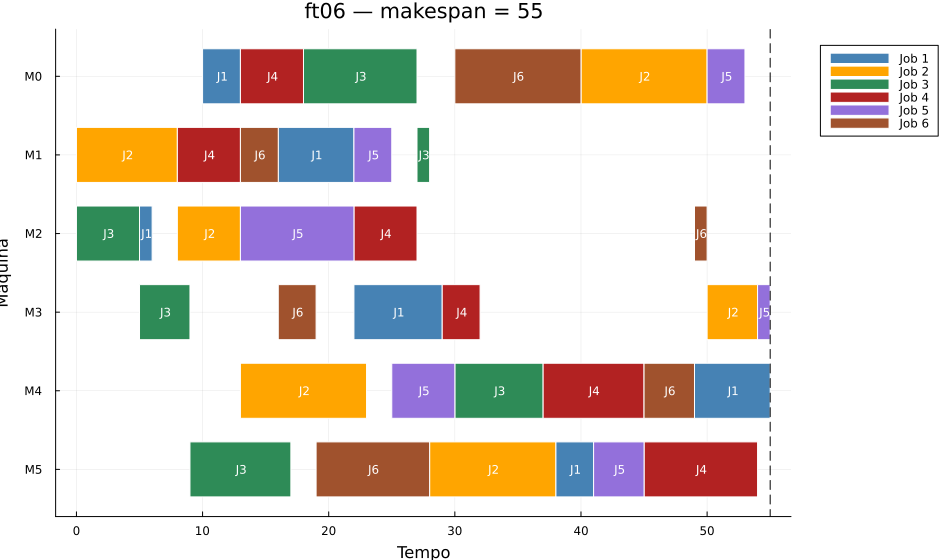

In [7]:
const PALETTE = [:steelblue, :orange, :seagreen, :firebrick, :mediumpurple,
                 :sienna, :goldenrod, :teal, :hotpink, :slategray]

function gantt_jsp(sol; title = "")
    m, mu, p, st = sol.m, sol.mu, sol.p, sol.start
    plt = plot(; legend = :outertopright, xlabel = "Tempo", ylabel = "Máquina",
                 yticks = (0:m-1, ["M$i" for i in 0:m-1]), yflip = true,
                 size = (950, 70m + 140), title = title)

    shown = Dict{Int,Bool}()
    for (j, k) in sol.OPS
        machine = mu[(j, k)]
        s0, d = st[(j, k)], p[(j, k)]
        y = machine
        col = PALETTE[(j - 1) % length(PALETTE) + 1]
        lbl = get(shown, j, false) ? "" : "Job $j"; shown[j] = true
        plot!(plt, Shape([s0, s0 + d, s0 + d, s0], [y - 0.35, y - 0.35, y + 0.35, y + 0.35]);
              fillcolor = col, linecolor = :white, linewidth = 1, label = lbl)
        annotate!(plt, s0 + d / 2, y, text("J$j", :white, :center, 8))
    end
    vline!(plt, [sol.cmax]; linestyle = :dash, color = :black, label = "")
    plot!(plt; ylims = (-0.6, m - 0.4))
    return plt
end

gantt_jsp(sol; title = "$INSTANCE — makespan = $(round(Int, sol.cmax))")

## Dificuldade computacional: instâncias maiores

O número de binárias cresce com o número de pares por máquina. Resolvemos algumas instâncias do
subconjunto com **limite de tempo** e comparamos o makespan obtido ao ótimo conhecido — para as
maiores, o solver tende a **não fechar o gap** dentro do tempo, ilustrando a explosão
combinatória do JSP.

In [ ]:
using Printf

testset = ["ft06", "la01", "la02", "ft10"]   # do menor ao maior/mais difícil
println(@sprintf("%-7s %6s %8s %8s %8s %8s %s",
        "inst", "n×m", "ótimo", "obtido", "gap", "#bin", "status"))
for name in testset
    path = joinpath(JSPDIR, "instances", name)
    mt   = instance_meta(joinpath(JSPDIR, "instances.json"), name)
    s    = solve_jsp(path; time_limit = 30.0)
    println(@sprintf("%-7s %3d×%-2d %8s %8d %8.3f %8d  %s",
            name, s.n, s.m, string(mt["optimum"]),
            round(Int, s.cmax), s.gap, s.nbin, string(s.status)))
end

## Leitura para a aula

- O **JSP** acopla, em cada máquina, a **mesma disjunção** do escalonamento de máquina única, e
  adiciona as **precedências** dos jobs — por isso o modelo disjuntivo *big-M* é a extensão
  natural do que vimos antes.
- O modelo dá o **makespan ótimo** para instâncias pequenas (`ft06` → 55 em ~1 s), mas a
  dificuldade explode: `ft10` (10×10) e as `la`/`abz` maiores normalmente **atingem o limite de
  tempo** com *gap* positivo.
- Daí a importância de **heurísticas e meta-heurísticas** (regras de prioridade, *shifting
  bottleneck*, busca tabu, algoritmos genéticos) e de formulações/cortes mais fortes para o JSP.

### Próximos passos sugeridos

1. **Formulação alternativa** *time-indexed* ou *rank-based* e comparação da relaxação.
2. **Warm-start** com uma regra de prioridade (p.ex. SPT/MWKR) via `set_start_value`.
3. Rodar o subconjunto inteiro e plotar **tempo × (n·m)** (curva de complexidade), reaproveitando
   o laço de benchmark do notebook anterior.